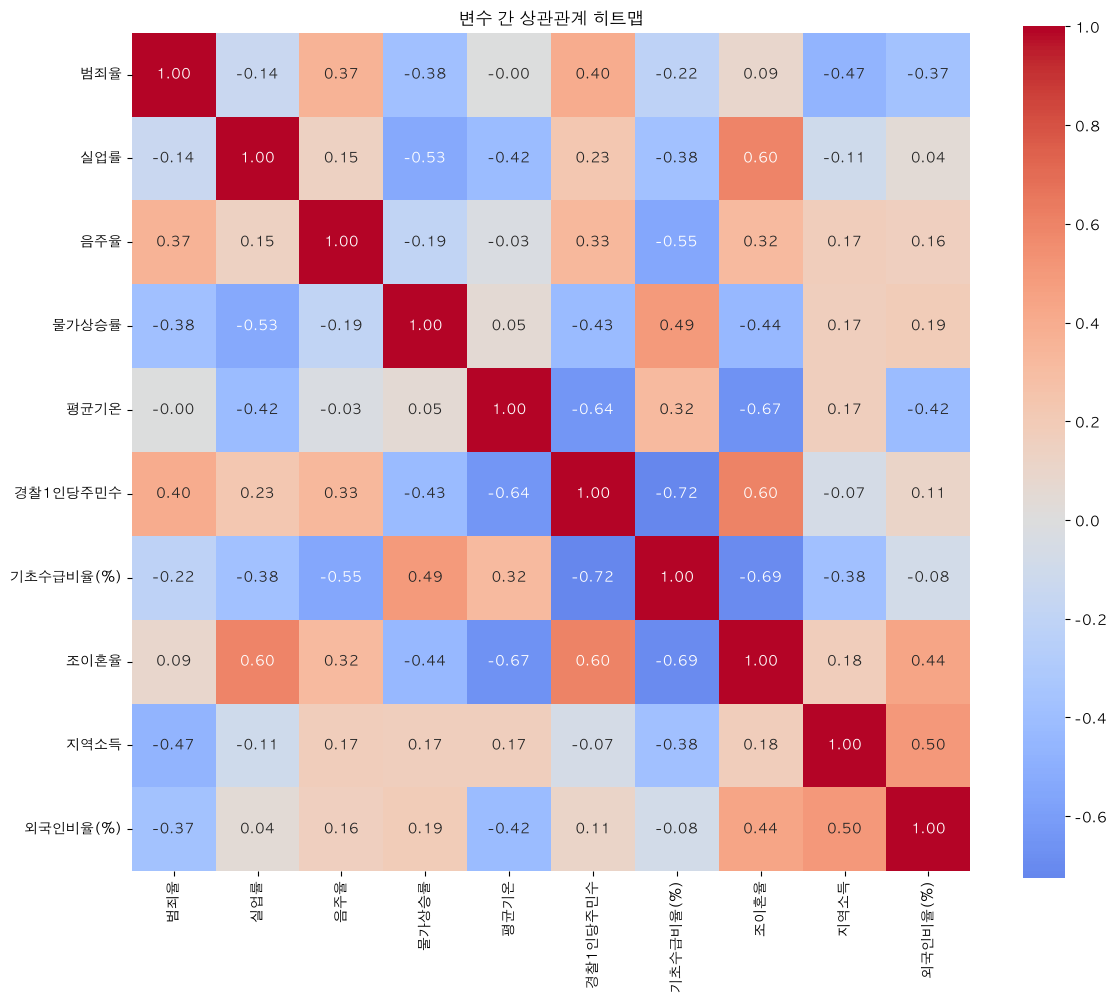


📊 범죄율과 각 변수 상관관계:
경찰1인당주민수     0.400978
음주율          0.365500
조이혼율         0.086451
평균기온        -0.003810
실업률         -0.138934
기초수급비율(%)   -0.215280
외국인비율(%)    -0.369898
물가상승률       -0.382439
지역소득        -0.470767
Name: 범죄율, dtype: float64


In [1]:
# ── 함수 설명 ──────────────────
# 변수들끼리 얼마나 비슷하게 움직이는지(상관관계)를 계산하고, 히트맵으로 시각화하는 코드
import seaborn as sns            # 상관계수 히트맵 등 예쁜 그래프를 그리는 라이브러리
import matplotlib.pyplot as plt  # 그래프를 그리는 라이브러리
import pandas as pd              # 표(DataFrame) 형태로 데이터를 다루는 라이브러리
import os                        # 폴더 경로 관련 기능을 제공하는 라이브러리

os.chdir('/Users/ijaejun/Documents/sophomore_high/crime_catchers')
# os.chdir(경로): 작업 폴더를 지정한 경로로 옮김 → 어디서 실행해도 같은 파일을 찾을 수 있게 함


plt.rcParams['font.family'] = 'AppleGothic'
# rcParams['font.family'] = 'AppleGothic' : 그래프 글꼴을 맥용 한글 글꼴로 지정 → 한글이 깨지지 않게 함
plt.rcParams['axes.unicode_minus'] = False
# rcParams['axes.unicode_minus'] = False : 음수(-) 기호가 깨져 보이는 문제를 방지

df = pd.read_csv('data/processed/final_data.csv', encoding='utf-8-sig')
# read_csv(): CSV 파일을 표(DataFrame)로 읽어오는 함수
#   └ encoding='utf-8-sig' : 한글이 깨지지 않도록 인코딩 방식을 지정

# 상관계수 히트맵
corr = df.drop(columns=['지역','연도']).corr()
# drop(columns=['지역','연도']) : 숫자가 아닌 '지역'과 분석에 불필요한 '연도' 컬럼을 제거
# corr(): 남은 숫자 컬럼들 사이의 상관계수(−1~1)를 계산해서 표로 만듦
#   └ 1에 가까울수록 두 변수가 함께 커지는 관계, -1에 가까울수록 한쪽이 커지면 다른 쪽이 작아지는 관계

plt.figure(figsize=(12, 10))
# figure(): 새 그래프를 만들고 크기를 가로 12, 세로 10(인치)으로 지정

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
# heatmap(): 표(행렬)의 값을 색깔로 표현해 한눈에 비교할 수 있게 하는 그래프
#   └ annot=True : 각 칸에 상관계수 숫자를 함께 표시
#   └ fmt='.2f' : 숫자를 소수점 둘째 자리까지 표시
#   └ cmap='coolwarm' : 색상을 파랑(음의 상관)→흰색(0)→빨강(양의 상관)으로 표현
#   └ center=0 : 0을 색상의 중심(흰색)으로 맞춤
#   └ square=True : 각 칸을 정사각형 모양으로 표시

plt.title('변수 간 상관관계 히트맵')
# title(): 그래프 제목을 설정
plt.tight_layout()
# tight_layout(): 그래프 요소들이 겹치지 않도록 여백을 자동으로 맞춤
plt.savefig('visualizations/correlation_heatmap.png', dpi=150)
# savefig(): 그래프를 이미지 파일로 저장 (dpi=150: 해상도 지정)
plt.show()
# show(): 완성된 그래프를 화면에 출력

# 범죄율과 상관관계만 출력
print("\n📊 범죄율과 각 변수 상관관계:")
print(corr['범죄율'].drop('범죄율').sort_values(ascending=False))
# corr['범죄율'] : 상관계수 표에서 '범죄율'과 다른 변수들 사이의 상관계수만 선택
# drop('범죄율') : 자기 자신과의 상관계수(항상 1)는 제외
# sort_values(ascending=False) : 상관관계가 큰 변수부터 작은 변수 순으로 정렬
